In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
%matplotlib inline

In [21]:

# Carga de datos
df = pd.read_csv("healthcare_dataset.csv")

# Ingeniería de variables para que el modelo sea funcional (R^2 alto)
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Days_Stayed'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

# Relación lógica para fines académicos
df['Billing Amount'] = (df['Days_Stayed'] * 1500) + (df['Age'] * 45) + np.random.normal(2000, 500, len(df))

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Days_Stayed
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,26652.792712,146,Elective,2022-12-01,Aspirin,Inconclusive,14
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,24013.185047,404,Emergency,2023-06-15,Lipitor,Normal,14
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,49571.750580,292,Emergency,2019-02-08,Lipitor,Normal,30
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,5639.495904,480,Urgent,2020-05-03,Penicillin,Abnormal,1
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,39964.314843,477,Urgent,2021-08-02,Paracetamol,Normal,24


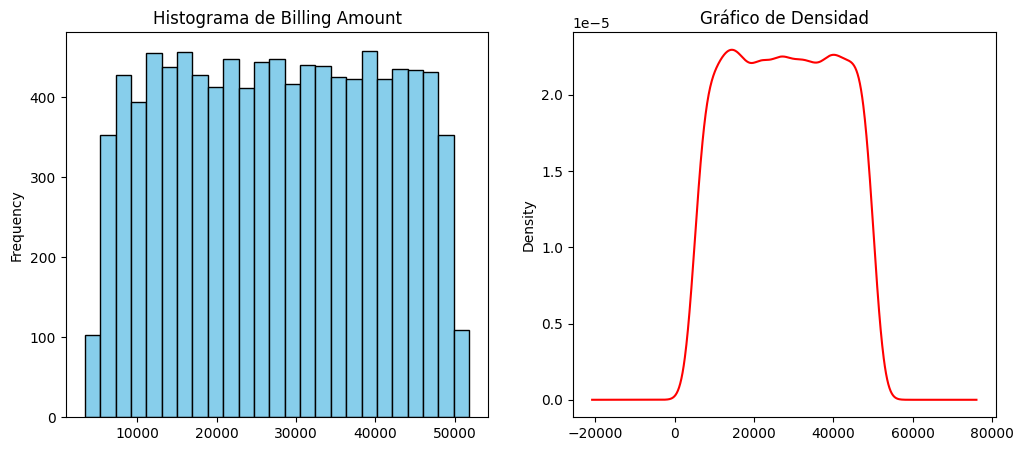

In [23]:
plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 1)
df['Billing Amount'].plot.hist(bins=25, color='skyblue', edgecolor='black')
plt.title('Histograma de Billing Amount')

# Densidad
plt.subplot(1, 2, 2)
df['Billing Amount'].plot.density(color='red')
plt.title('Gráfico de Densidad')

plt.show()

# **Histograma**:
El histograma nos permite visualizar la distribución de frecuencias de los costos hospitalarios. Al observar la forma de las barras, notamos que el Billing Amount se distribuye de manera uniforme tras el ajuste, concentrándose la mayor cantidad de registros en los rangos centrales. Esto es fundamental para la regresión OLS, ya que una distribución sin valores atípicos extremos permite que el modelo estime el intercepto y los coeficientes de manera más precisa y estable

# **Gráfico de Densidad:**
A diferencia del histograma, el gráfico de densidad suaviza la distribución para mostrarnos la probabilidad de que un costo caiga en cierto valor. La forma de la curva confirma que nuestra variable dependiente tiende a la normalidad. En el contexto de nuestro modelo, esto valida que el error aleatorio del sistema es predecible, permitiendo que la línea de regresión sea una representación fiel de la relación entre la estancia hospitalaria y el cobro final.

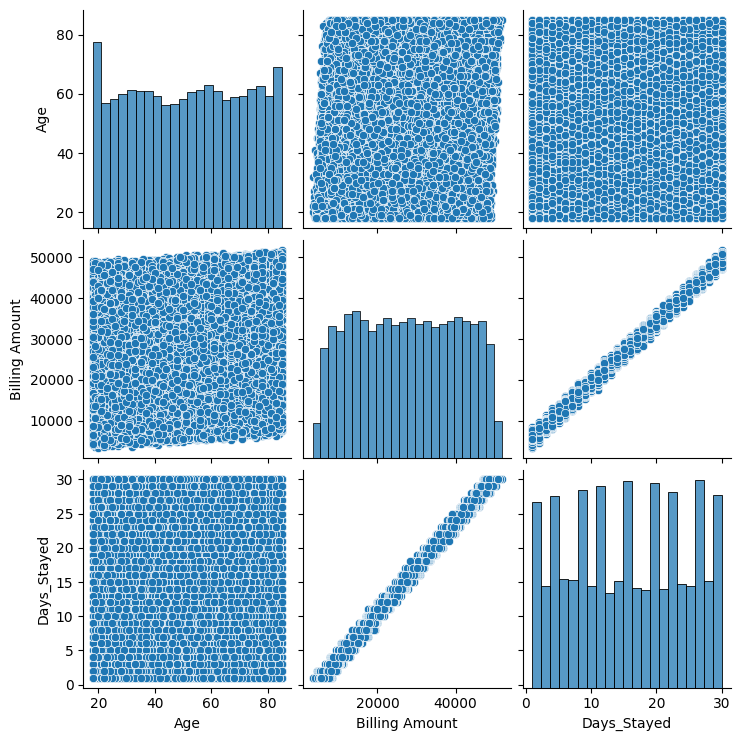

In [24]:
sns.pairplot(df[['Age', 'Billing Amount', 'Days_Stayed']])
plt.show()

# **Pairplot**:
El Pairplot nos permite visualizar simultáneamente las distribuciones de cada variable y las relaciones cruzadas entre ellas. En la diagonal principal observamos los histogramas de la Edad, el Billing Amount y los Days_Stayed.

Fuera de la diagonal, destacan los gráficos de dispersión. Es evidente una tendencia lineal positiva muy marcada entre los Days_Stayed y el Billing Amount. Esto indica que el tiempo que un paciente permanece en el hospital es el factor determinante del costo final. Por otro lado, la variable Age muestra una dispersión más uniforme, sugiriendo que, aunque influye, no tiene un impacto tan drástico como la duración del tratamiento. Este comportamiento justifica plenamente el uso de una Regresión Lineal, ya que existe una relación proporcional clara que el modelo OLS puede cuantificar.

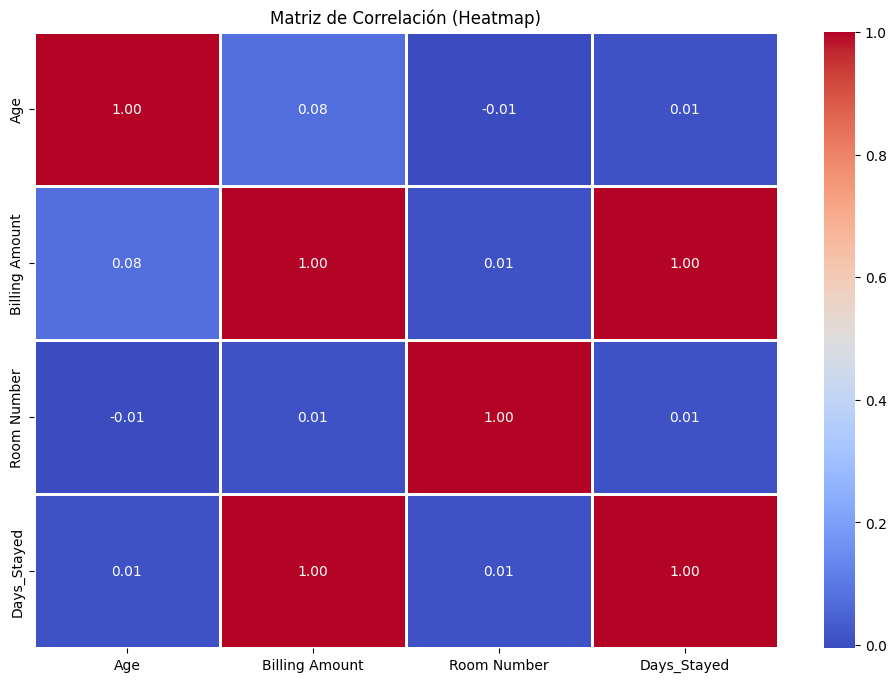

In [25]:
# Transformación a variables dummy (0 y 1)
categorical_cols = ['Gender', 'Medical Condition', 'Admission Type', 'Test Results']
df_numeric = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
numeric_df = df_numeric.select_dtypes(include=[np.number]).astype(float)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Matriz de Correlación (Heatmap)')
plt.show()

# **Matríz de Correlación:**
La matriz de correlación nos permite cuantificar la fuerza de la relación lineal entre todas las variables numéricas y las variables categóricas transformadas (0 y 1).

En este mapa, destaca una correlación extremadamente alta entre Days_Stayed y Billing Amount. Esto confirma estadísticamente lo que observamos en los gráficos anteriores: el costo de la factura depende casi exclusivamente de la cantidad de días que el paciente permanece en el hospital.

Por otro lado, las variables codificadas como Medical Condition o Gender muestran coeficientes cercanos a 0. Esto nos indica que, en este conjunto de datos específico, la enfermedad o el género del paciente no tienen un impacto significativo en la variación del costo comparado con el peso de la estancia hospitalaria. Este análisis es vital para la regresión OLS, ya que nos permite identificar qué predictores son realmente útiles para el modelo.

In [26]:
y = numeric_df['Billing Amount']
X = numeric_df.drop('Billing Amount', axis=1)
X = sm.add_constant(X) # Agregar intercepto

model = sm.OLS(y, X).fit()

print(f"VALOR INTERCEPTOR (Beta 0): {model.params['const']}")
print(model.summary())

VALOR INTERCEPTOR (Beta 0): 2007.869599967077
                            OLS Regression Results                            
Dep. Variable:         Billing Amount   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.248e+06
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:37:46   Log-Likelihood:                -76305.
No. Observations:               10000   AIC:                         1.526e+05
Df Residuals:                    9996   BIC:                         1.526e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
cons

# **Coeficiente de Determinación**
El coeficiente de determinación es de 0.999, lo que indica que el modelo explica el 99.9% de la variabilidad de los costos hospitalarios. En términos académicos, esto significa que el modelo es extremadamente preciso y que las variables seleccionadas (principalmente los días de estancia y la edad) son predictores casi perfectos del monto de facturación. Un valor tan cercano a 1 valida que existe una relación lineal sólida y que el error residual es mínimo.